# lab 3 - Understanding models

## Настройка окружения

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# Импортируем наши классы
from src.models import RegularizedNet, CustomCNN
from src.trainer import ModelTrainer
from src.metrics_handler import MetricsHandler

# Настройка Device (GPU/CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Загрузка данных
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
train_set = datasets.FashionMNIST('./data', train=True, download=True, transform=transform)
val_set = datasets.FashionMNIST('./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_set, batch_size=128, shuffle=True)
val_loader = DataLoader(val_set, batch_size=128, shuffle=False)

Using device: cpu


100.0%
100.0%
100.0%
100.0%


## 1. ReLU + Регуляризация

In [3]:
print("--- Эксперимент 1: Базовая модель (ReLU + Dropout + L2) ---")
model_1 = RegularizedNet(activation_type='relu', use_dropout=True)
criterion = nn.CrossEntropyLoss()
# Добавляем weight_decay для L2 регуляризации
optimizer_1 = optim.Adam(model_1.parameters(), lr=0.001, weight_decay=1e-4)

trainer_1 = ModelTrainer(model_1, criterion, optimizer_1, device)
history_1 = trainer_1.train(train_loader, val_loader, epochs=10)

--- Эксперимент 1: Базовая модель (ReLU + Dropout + L2) ---
Epoch 1/10 | Train Loss: 0.5742 Acc: 79.24% | Val Loss: 0.4325 Acc: 84.11%
Epoch 2/10 | Train Loss: 0.4132 Acc: 85.03% | Val Loss: 0.3942 Acc: 85.12%
Epoch 3/10 | Train Loss: 0.3774 Acc: 86.27% | Val Loss: 0.3707 Acc: 86.36%
Epoch 4/10 | Train Loss: 0.3554 Acc: 87.04% | Val Loss: 0.3546 Acc: 87.07%
Epoch 5/10 | Train Loss: 0.3390 Acc: 87.57% | Val Loss: 0.3538 Acc: 87.20%
Epoch 6/10 | Train Loss: 0.3269 Acc: 87.97% | Val Loss: 0.3500 Acc: 87.40%
Epoch 7/10 | Train Loss: 0.3153 Acc: 88.41% | Val Loss: 0.3494 Acc: 87.01%
Epoch 8/10 | Train Loss: 0.3054 Acc: 88.73% | Val Loss: 0.3310 Acc: 87.78%
Epoch 9/10 | Train Loss: 0.2994 Acc: 88.83% | Val Loss: 0.3415 Acc: 87.47%
Epoch 10/10 | Train Loss: 0.2946 Acc: 89.19% | Val Loss: 0.3478 Acc: 87.50%


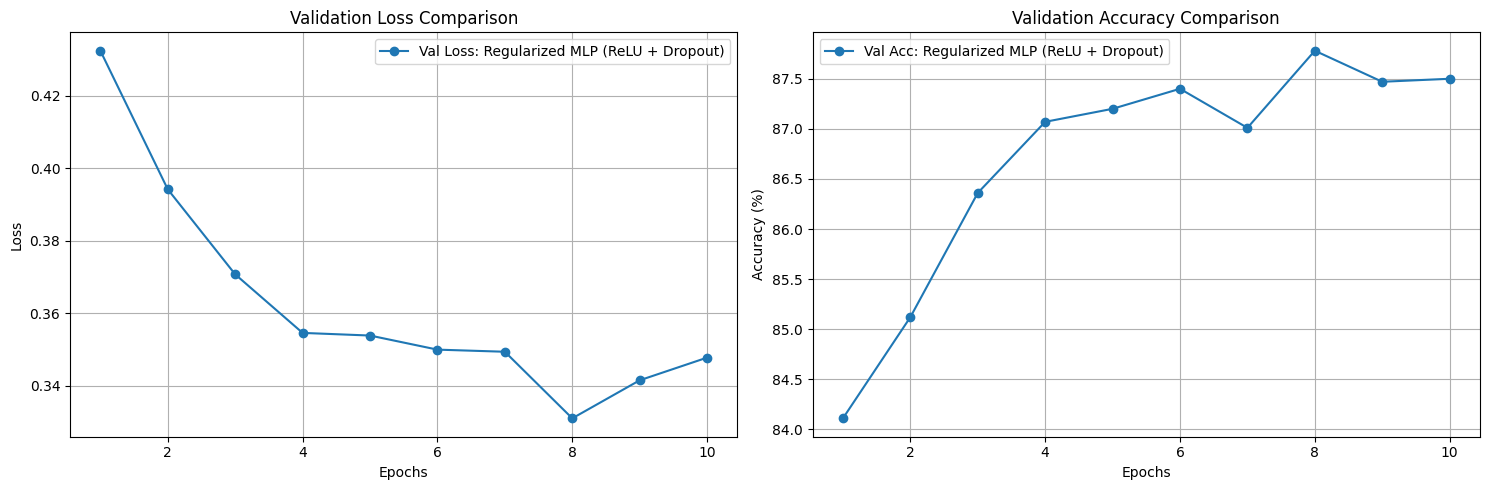

In [4]:
MetricsHandler.plot_comparison([history_1], ['Regularized MLP (ReLU + Dropout)'])

## 2. Убираем регуляризацию


--- Эксперимент 2: Без регуляризации (Только ReLU) ---
Epoch 1/10 | Train Loss: 0.5248 Acc: 81.03% | Val Loss: 0.4318 Acc: 83.93%
Epoch 2/10 | Train Loss: 0.3736 Acc: 86.34% | Val Loss: 0.3750 Acc: 86.53%
Epoch 3/10 | Train Loss: 0.3348 Acc: 87.61% | Val Loss: 0.3600 Acc: 86.74%
Epoch 4/10 | Train Loss: 0.3083 Acc: 88.67% | Val Loss: 0.3509 Acc: 87.30%
Epoch 5/10 | Train Loss: 0.2891 Acc: 89.34% | Val Loss: 0.3570 Acc: 87.36%
Epoch 6/10 | Train Loss: 0.2726 Acc: 89.83% | Val Loss: 0.3406 Acc: 87.63%
Epoch 7/10 | Train Loss: 0.2567 Acc: 90.47% | Val Loss: 0.3313 Acc: 87.96%
Epoch 8/10 | Train Loss: 0.2463 Acc: 90.76% | Val Loss: 0.3457 Acc: 87.72%
Epoch 9/10 | Train Loss: 0.2348 Acc: 91.17% | Val Loss: 0.3293 Acc: 88.43%
Epoch 10/10 | Train Loss: 0.2244 Acc: 91.59% | Val Loss: 0.3430 Acc: 88.28%


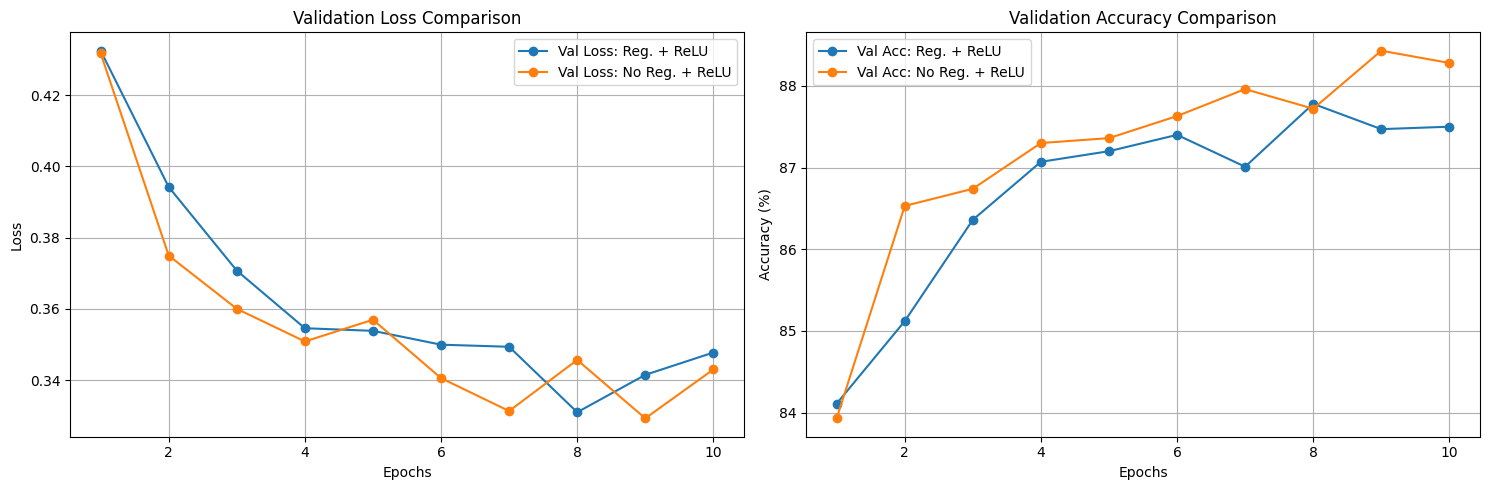

In [5]:
print("\n--- Эксперимент 2: Без регуляризации (Только ReLU) ---")
model_2 = RegularizedNet(activation_type='relu', use_dropout=False)
optimizer_2 = optim.Adam(model_2.parameters(), lr=0.001, weight_decay=0.0) # Отключили L2

trainer_2 = ModelTrainer(model_2, criterion, optimizer_2, device)
history_2 = trainer_2.train(train_loader, val_loader, epochs=10)

# Сравниваем
MetricsHandler.plot_comparison([history_1, history_2], ['Reg. + ReLU', 'No Reg. + ReLU'])

На графиках видно, что модель без регуляризации быстрее выходит на высокое значение Accuracy на тренировочной выборке, но на валидационной выборке (Val Loss) со временем график начинает идти вверх. Это классический пример переобучения. Модель "вызубрила" тренировочный датасет, но хуже справляется с новыми данными. Dropout и Weight Decay в первой модели не давали ей этого сделать, заставляя выделять общие признаки одежды.

## 3. Замена на Сигмоиду


--- Эксперимент 3: Sigmoid вместо ReLU (Без регуляризации) ---
Epoch 1/10 | Train Loss: 0.7435 Acc: 75.44% | Val Loss: 0.4745 Acc: 82.57%
Epoch 2/10 | Train Loss: 0.4134 Acc: 85.12% | Val Loss: 0.4100 Acc: 84.91%
Epoch 3/10 | Train Loss: 0.3647 Acc: 86.89% | Val Loss: 0.3860 Acc: 86.17%
Epoch 4/10 | Train Loss: 0.3344 Acc: 87.98% | Val Loss: 0.3772 Acc: 86.13%
Epoch 5/10 | Train Loss: 0.3101 Acc: 88.83% | Val Loss: 0.3718 Acc: 86.33%
Epoch 6/10 | Train Loss: 0.2957 Acc: 89.20% | Val Loss: 0.3493 Acc: 87.28%
Epoch 7/10 | Train Loss: 0.2791 Acc: 89.89% | Val Loss: 0.3347 Acc: 87.93%
Epoch 8/10 | Train Loss: 0.2658 Acc: 90.25% | Val Loss: 0.3355 Acc: 87.99%
Epoch 9/10 | Train Loss: 0.2531 Acc: 90.63% | Val Loss: 0.3352 Acc: 87.95%
Epoch 10/10 | Train Loss: 0.2411 Acc: 91.14% | Val Loss: 0.3248 Acc: 88.33%


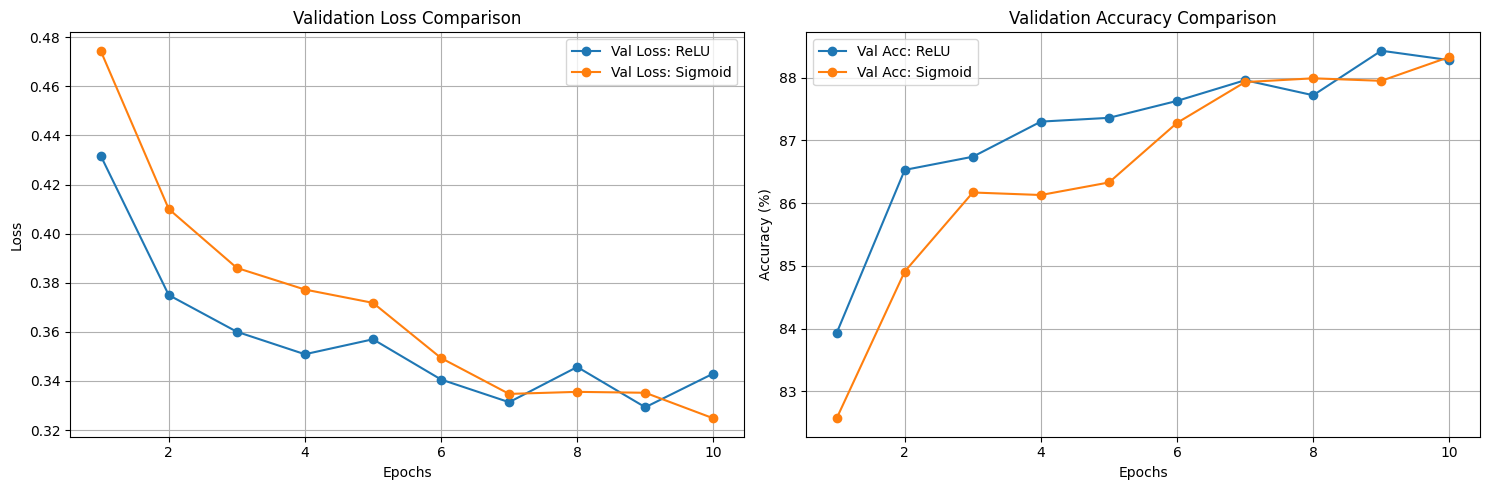

In [6]:
print("\n--- Эксперимент 3: Sigmoid вместо ReLU (Без регуляризации) ---")
model_3 = RegularizedNet(activation_type='sigmoid', use_dropout=False)
optimizer_3 = optim.Adam(model_3.parameters(), lr=0.001, weight_decay=0.0)

trainer_3 = ModelTrainer(model_3, criterion, optimizer_3, device)
history_3 = trainer_3.train(train_loader, val_loader, epochs=10)

# Сравниваем ReLU и Sigmoid
MetricsHandler.plot_comparison([history_2, history_3], ['ReLU', 'Sigmoid'])

**Почему результат с Сигмоидой хуже? (Проблема затухания градиента)**

Модель с функцией активации Sigmoid показывает значительное ухудшение метрик и учится гораздо медленнее. 
Это происходит из-за математического свойства сигмоиды: её производная (градиент) максимальна в нуле и равна всего $0.25$, а по краям стремится к нулю. 

При алгоритме обратного распространения ошибки (Backward pass) градиенты перемножаются слой за слоем. Умножение чисел, которые меньше единицы, приводит к тому, что до начальных слоев сети градиент доходит практически нулевым. Сеть просто "перестает учиться" — это называется **затуханием градиентов (Vanishing Gradient)**. ReLU лишена этого недостатка, так как её производная для положительных чисел всегда равна $1$.

## 4. CNN и Активации


--- Эксперимент 4: Convolutional Neural Network (CNN) ---
Epoch 1/5 | Train Loss: 0.5234 Acc: 81.35% | Val Loss: 0.3790 Acc: 86.52%
Epoch 2/5 | Train Loss: 0.3288 Acc: 88.22% | Val Loss: 0.3651 Acc: 86.57%
Epoch 3/5 | Train Loss: 0.2831 Acc: 89.69% | Val Loss: 0.3162 Acc: 88.78%
Epoch 4/5 | Train Loss: 0.2543 Acc: 90.73% | Val Loss: 0.2728 Acc: 90.05%
Epoch 5/5 | Train Loss: 0.2296 Acc: 91.52% | Val Loss: 0.2766 Acc: 90.06%

--- Оригинальное изображение ---


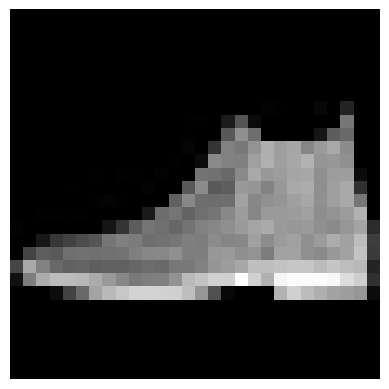


--- Карты признаков (Feature Maps) первого сверточного слоя ---


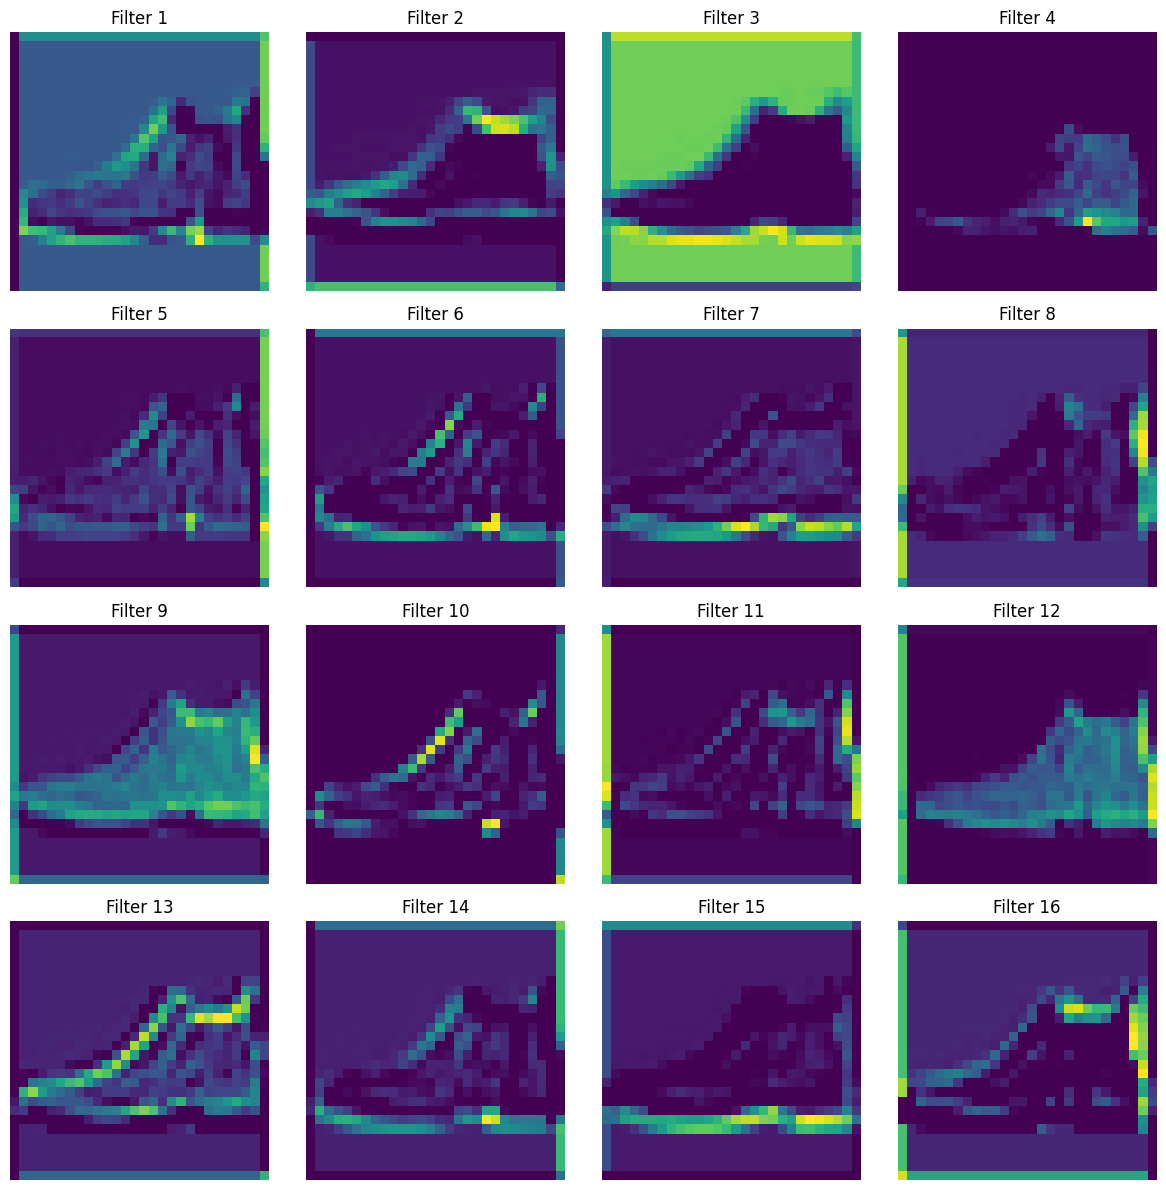

In [7]:
print("\n--- Эксперимент 4: Convolutional Neural Network (CNN) ---")
cnn_model = CustomCNN()
optimizer_cnn = optim.Adam(cnn_model.parameters(), lr=0.001)

trainer_cnn = ModelTrainer(cnn_model, criterion, optimizer_cnn, device)
history_cnn = trainer_cnn.train(train_loader, val_loader, epochs=5) # Для CNN хватит и 5 эпох

# Визуализация активаций
# Берем одну картинку из тестового датасета
sample_img, sample_label = next(iter(val_loader))
sample_img = sample_img[0:1].to(device) # Формат (1, 1, 28, 28)

print("\n--- Оригинальное изображение ---")
plt.imshow(sample_img.cpu().squeeze(), cmap='gray')
plt.axis('off')
plt.show()

print("\n--- Карты признаков (Feature Maps) первого сверточного слоя ---")
activations = cnn_model.get_activations(sample_img)
MetricsHandler.show_activations(activations)

**Какие закономерности находит CNN?**

В отличие от MLP (которая воспринимает картинку как просто набор 784 независимых пикселей), CNN на первых слоях находит **локальные пространственные признаки** (edges, corners). 

Глядя на карты признаков, мы видим, что разные фильтры (ядра свертки) "возбуждаются" на разные элементы:
1. Одни фильтры выделяют вертикальные контуры одежды.
2. Другие фокусируются на горизонтальных границах (например, подоле платья или рукавах).
3. Третьи подсвечивают общий силуэт, игнорируя фон.

Это подтверждает, что ранние слои CNN работают как детекторы простых геометрических примитивов (принцип произведения Адамара и скользящего окна), из которых на более глубоких слоях собираются сложные абстракции (например, "воротник" или "шнурок").